In [1]:
import pandas as pd
import numpy as np

In [2]:

df = pd.read_csv('train_multi_class.csv')

In [6]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,target
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,...,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000
mean,29.995753,30.034725,30.010671,29.968977,29.997385,30.033146,29.964921,29.974007,1000.064813,999.796399,...,54.956507,49.809852,49.958858,49.969886,5175.958370,0.000103,200.019039,0.031110,1.005385,1.743495
std,8.114195,8.787587,9.781122,8.565687,8.034021,8.641522,11.027776,8.218518,63.816475,62.859374,...,11.143903,35.642893,35.138128,36.159536,332.673820,0.000353,19.332253,5.220802,0.042758,1.427077
min,9.943455,8.837328,7.385609,8.997332,8.381793,6.552644,5.730914,7.124477,852.336759,851.459452,...,31.367694,-26.491879,-24.242588,-25.456721,3921.337737,-0.001394,119.391766,-23.736318,0.816156,0.000000
25%,23.264890,22.404690,21.068458,22.681244,23.132443,22.646282,19.231689,23.156619,942.233990,942.243295,...,44.086894,15.905965,17.235155,15.374776,4949.274586,-0.000136,187.041668,-3.492215,0.976414,0.000000
50%,30.021826,30.083630,29.976825,29.920583,30.002357,29.938551,29.828216,30.030690,1000.008966,999.965650,...,54.964872,49.577768,49.970222,50.199118,5173.193275,0.000101,200.125331,0.027316,1.005113,2.000000
75%,36.719011,37.626907,38.953300,37.252176,36.833733,37.502616,40.735190,36.847408,1057.964316,1057.350507,...,65.793989,83.519190,82.677570,84.365736,5399.327997,0.000342,213.033288,3.547335,1.034437,3.000000
max,50.761574,51.474524,54.102329,52.413317,51.268375,51.897246,53.194587,50.272845,1145.446000,1140.889236,...,78.053728,124.932696,128.032983,129.759874,6664.819620,0.001455,278.161539,22.812828,1.173081,4.000000


In [7]:
df.shape

(49999, 41)

In [5]:
for col in df.columns:
  df = df[~df[col].isna()]

In [8]:
testdf = df.sample(frac = 0.4,random_state=42)
df.drop(testdf.index,inplace = True)

In [9]:
xs = df.drop(['target'],axis = 1)
reg_targets = df.target
txs = testdf.drop(['target'],axis = 1)
target = testdf.target


In [10]:
metric = pd.DataFrame({'label' : xs.columns,
              'mean' : np.mean(xs,axis =0),
              'std' : np.std(xs,axis = 0)})

In [11]:
for col in xs.columns:
  xs[col] = (xs[col] - np.mean(xs[col]))/np.std(xs[col])

In [12]:
xs.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39
count,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,...,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,2.999900e+04,29999.000000,2.999900e+04,2.999900e+04,2.999900e+04
mean,-2.250127e-16,4.699213e-16,-1.504032e-16,4.547625e-16,-3.183338e-16,2.036957e-16,-1.255334e-16,-3.098070e-16,5.021336e-16,-5.959284e-16,...,2.297498e-16,6.346542e-16,9.000508e-17,1.088351e-16,-1.226911e-16,1.819050e-15,0.000000,-4.699213e-16,2.250127e-17,1.799154e-15
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,...,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017,1.000017e+00,1.000017e+00,1.000017e+00
min,-2.472390e+00,-2.417871e+00,-2.315306e+00,-2.380977e+00,-2.680239e+00,-2.729756e+00,-2.035196e+00,-2.779767e+00,-2.318216e+00,-2.365283e+00,...,-2.234667e+00,-2.108388e+00,-2.107280e+00,-2.110347e+00,-2.087465e+00,-3.776481e+00,-4.244368,-4.034909e+00,-4.558945e+00,-4.426650e+00
25%,-8.335432e-01,-8.636604e-01,-9.111403e-01,-8.531151e-01,-8.559858e-01,-8.557829e-01,-9.724112e-01,-8.307510e-01,-9.009830e-01,-9.139189e-01,...,-8.807855e-01,-9.746715e-01,-9.476999e-01,-9.290595e-01,-9.534972e-01,-6.853749e-01,-0.674743,-6.696231e-01,-6.741272e-01,-6.731893e-01
50%,-1.166229e-04,6.532519e-03,-2.419782e-03,-1.566864e-02,-1.843000e-03,-1.480526e-03,-1.558015e-02,2.175940e-03,1.627476e-03,2.585351e-04,...,3.429610e-03,-6.206309e-03,-8.490286e-03,1.959078e-03,5.942588e-03,-1.224130e-02,-0.005814,6.338620e-03,-4.951143e-03,-7.335505e-03
75%,8.278766e-01,8.603893e-01,9.121177e-01,8.527428e-01,8.532337e-01,8.657091e-01,9.791133e-01,8.385821e-01,9.067847e-01,9.181955e-01,...,8.804052e-01,9.745272e-01,9.466286e-01,9.352098e-01,9.551542e-01,6.708355e-01,0.679929,6.768112e-01,6.735333e-01,6.729295e-01
max,2.566402e+00,2.436424e+00,2.467486e+00,2.628758e+00,2.547404e+00,2.527687e+00,2.107620e+00,2.427311e+00,2.280667e+00,2.246166e+00,...,2.301438e+00,2.081810e+00,2.103317e+00,2.208866e+00,2.172298e+00,4.485797e+00,3.531846,4.034311e+00,4.384110e+00,3.918532e+00


In [13]:
xs.shape

(29999, 40)

In [14]:
class Neuron:
    __slots__ = ['data', 'grad', 'children', '_backward']
    def __init__(self, data,children = (),_backward = lambda : None):
        self.data = data
        self.grad = 0.0
        self.children = children
        self._backward = lambda : None

    def __mul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data*other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __add__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out

    def __sub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Neuron(self.data) if self.data > 0 else Neuron(0)
        out.children = (self,)
        def _backward():
            self.grad += out.grad*1 if self.data > 0 else 0
        out._backward = _backward
        return out

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __pow__(self,other : float):
        # other = other if isinstance(other,Neuron) else Neuron(other) we are not doing this cuz
        # if other.data < 0 we might have to face a problem of get undefined
        # to avoid that I am considering other over here as an int variable only
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out = Neuron(self.data**other)
        out.children = (self,)
        out._backward = _backward
        return out

    def __radd__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out

    def __rsub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data * other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out



    def __rpow__(self,other : float):
        out = Neuron(self.data**other)
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out.children = (self,other)
        out._backward = _backward
        return out

    def __neg__(self):
        out = Neuron(-self.data)
        out.children = (self,)
        def _backward():
            self.grad += -1.0*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        out = Neuron((np.exp(2*self.data) - 1)/(np.exp(2*self.data) + 1))
        out.children = (self,)
        def _backward():
            self.grad += out.grad*(1 - out.data ** 2)
        out._backward = _backward
        return out

    def log(self):
        out = Neuron(np.log(np.maximum(self.data, 1e-12)), (self,))
        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Neuron(np.exp(self.data), (self,))
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Neuron({self.data} | grad {self.grad})"


    def backward(self):

        topo = []
        visited = set()

        stack = [(self, 0)]

        while stack:
            node, state = stack.pop()
            if state == 0:
                if node in visited:
                    continue
                visited.add(node)

                stack.append((node, 1))

                for child in node.children:
                    if isinstance(child, Neuron) and child not in visited:
                        stack.append((child, 0))
            else:
                topo.append(node)


        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Node(Module):
    __slots__ = ['w', 'b', 'nin', 'nonlin']
    def __init__(self, nin, nonlin=True):
        # intializing the default mode be a relu unit with He activation
        self.w = [Neuron(np.random.normal(0,np.sqrt(2/nin))) for _ in range(nin)]
        self.b = Neuron(0)
        self.nin = nin
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout,weight_intializer = 'He' ,nonlin = False ,**kwargs):
        self.neurons = [Node(nin, nonlin) for _ in range(nout)]
        def He():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / neuron.nin))) for _ in range(neuron.nin)]
        def Xavier():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / (neuron.nin + nout)))) for _ in range(neuron.nin)]
        if weight_intializer == 'He':
            He()
        elif weight_intializer == 'Xavier':
            Xavier()
        else:
            raise ValueError(f'Unknown weight initialization : {weight_intializer}')

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
class Softmax(Module):
    def __init__(self, nfeatures):
        self.nfeatures = nfeatures

    def __call__(self, x):
        exp_x = [a.exp() for a in x]
        exp_sum = sum(exp_x)
        return [expi / exp_sum for expi in exp_x]

def sparse_categorical_crossentropy(logits, target):
    max_val = max(l.data for l in logits)
    shifted_logits = [l - max_val for l in logits]
    logitsexp = [logit.exp() for logit in logits]
    total = sum(logitsexp)
    probs = [le / total for le in logitsexp]
    return probs[int(target)].log() * Neuron(-1.0)


class MLP(Module):

    def __init__(self, Layers):
        self.x = None
        self.y = None
        self.layers = Layers
        self.params = self.parameters()
        self.m = [0]*len(self.params)
        self.v = [0]*len(self.params)
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

    def fit(self,x,y,optimizer = 'adam',epochs = 1000,batchsize = 256,lrate = 0.01):
        self.x = x
        self.y = y
        self.optimizer = optimizer
        self.epoch = 1
        self.epoch_limit = epochs

        def gd(learning_rate = 0.001):
          for param in self.parameters():
            param.data -= learning_rate*param.grad

        def adam(learning_rate = 0.001):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            hat_m = [_m / (1 - 0.9 ** self.epoch) for _m in self.m]
            hat_v = [_v / (1 - 0.999 ** self.epoch) for _v in self.v]
            r_v = [np.sqrt(1/(_hat_v + 0.1**4)) for _hat_v in hat_v]
            for params,_hat_m,_r_v in zip(self.parameters(),hat_m,r_v):
                params.data -= learning_rate*_hat_m*_r_v

        def RMSprop(learning_rate = 0.001):
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            r_v = [(1/(np.sqrt(_hat_v) + 0.1**4)) for _hat_v in self.v]
            for params,_r_v in zip(self.parameters(),r_v):
                params.data -= learning_rate*_r_v*params.grad

        def momentum(learning_rate = 0.01):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            for params,_hat_m in zip(self.parameters(),self.m):
                params.data -= learning_rate*_hat_m

        if self.optimizer == 'adam':
            update_step = adam
        elif self.optimizer =='RMSprop':
            update_step = RMSprop
        elif self.optimizer =='momentum':
            update_step = momentum
        elif self.optimizer == 'gd':
          update_step = gd
        else:
            raise ValueError(f'Unknown Optimizer : {self.optimizer}')
        loss = []
        lr = lrate
        patience = 0
        i = 0
        batch_size = batchsize
        while self.epoch <= self.epoch_limit:
          epoch_loss = Neuron(0.0)
          for _ in range(0,self.x.shape[0],batch_size):
            batch = self.x[_:min(_+batch_size,self.x.shape[0] - 1)]
            self.zero_grad()
            y_pred = np.array([self(x) for x in batch])
            scce = []
            for logits,c_target in zip(y_pred,self.y[_:min(_+batch_size,self.x.shape[0] - 1)]):
                scce.append(sparse_categorical_crossentropy(logits,c_target))
            cost_t = sum(scce)
            cost = cost_t * (1.0/len(y_pred))
            epoch_loss += cost
            cost.backward()
            print(f"Batch {(_//batch_size + 1)} | Loss: {cost.data}    ",end = '\r')
            update_step(lr)
            for p in self.parameters():
              p.children = () # Break references
              p._backward = lambda: None
          print(f"Epoch {self.epoch} | Loss: {epoch_loss.data/(self.x.shape[0]//batch_size)}")
          loss.append(cost.data)
          cost = None
          y_pred = None
          scce = None
          self.epoch += 1
          if ((len(loss) > 3 and np.abs((loss[-2] - loss[-1])/loss[-1]  < 0.05) and cost.data < 0.2 )and lr*0.8 >1e-5 ):
            lr = lr*0.8
            print(f"\n teduced lr to {lr}")
          if(len(loss) > 3 and loss[-2] < loss[-1]):
            patience += 1
            if (patience > 3 ) or cost.data < 0.01:
              patience = 0
              print("/n Early stopping")
              break

        return loss
    def predict(self,x):
      preds = []
      for xs in x:
          # convert to Neuron if needed
          xs_neuron = [Neuron(xi) if not isinstance(xi, Neuron) else xi for xi in xs]
          y_pred = self(xs_neuron)  # forward pass
          preds.append(y_pred.data if isinstance(y_pred,Neuron) else y_pred)
      return np.array(preds)
class BatchNorm1dNode(Module):

    def __init__(self, n_features):

        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features

    def __call__(self, x):

        assert len(x) == self.n_features

        mean = sum(x, Neuron(0.0)) / self.n_features
        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) / self.n_features
        std = (var + 1e-5) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"BatchNorm1dNode({self.n_features})"


class BatchNorm1d(Module):

    def __init__(self, n_features, **kwargs):
        self.nodes = [BatchNorm1dNode(n_features)]

    def __call__(self, x):
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"BatchNorm1d of [{', '.join(str(n) for n in self.nodes)}]"

class LayerNorm1dNode(Module):

    def __init__(self, n_features, eps=1e-5):
        # gamma and beta for each feature (like weights + bias)
        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features
        self.eps = eps

    def __call__(self, x):

        assert len(x) == self.n_features


        mean = sum(x, Neuron(0.0)) * (1.0 / self.n_features)


        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) * (1.0 / self.n_features)

        std = (var + self.eps) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)

        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"LayerNorm1dNode({self.n_features})"

class LayerNorm1d(Module):


    def __init__(self, n_features, **kwargs):
        self.nodes = [LayerNorm1dNode(n_features)]

    def __call__(self, x):
        # x: list[Neuron] for ONE sample
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"LayerNorm1d of [{', '.join(str(n) for n in self.nodes)}]"




In [16]:
model = MLP(
    (Layer(nin = 20,nout=10,nonlin = True),
     Layer(nin = 10,nout = 5, nonlin = True),
     BatchNorm1d(5),
     Layer(nin = 5,nout = 5)
    )
)

In [17]:
len(model.params)

305

In [19]:
loss = [np.float64(1.082052330042584)]

In [29]:
loss += model.fit(xs.to_numpy(),reg_targets.to_numpy(),epochs = 1,batchsize= 256 ,optimizer='adam',lrate = 0.005)

Epoch 1 | Loss: 1.1011056821872205


In [31]:
loss

[np.float64(1.082052330042584),
 np.float64(0.9620431818998264),
 np.float64(1.0223173972387518),
 np.float64(0.9487421728978195),
 np.float64(1.0065089420769864),
 np.float64(1.036975058011103)]

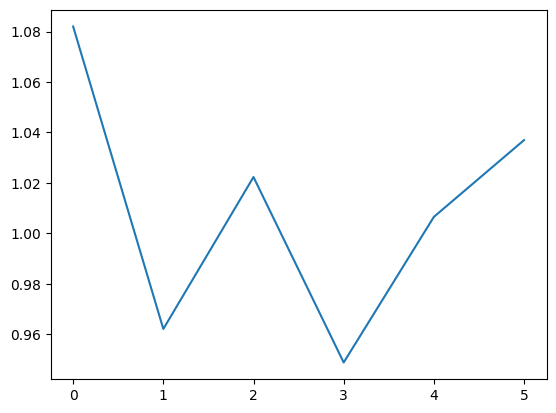

In [30]:
import matplotlib.pyplot as plt
plt.plot(loss)

In [32]:
for col in txs.columns:
  a = metric.loc[metric.label == col]
  txs[col] = (txs[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

/tmp/ipython-input-3568290101.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  txs[col] = (txs[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [40]:
import numpy as np

def get_f1_macro(y_true, y_pred):
    """
    y_true: 1D array of actual class labels (e.g., [0, 1, 2])
    y_pred_logits: 2D array from model.predict() (probabilities or raw scores)
    """
    # 1. Convert logits/probabilities to class predictions
    # If y_pred_logits is already class labels, skip this step
    # y_pred = np.argmax(y_pred_logits, axis=1)

    classes = np.unique(y_true)
    f1_scores = []

    for c in classes:
        # True Positives, False Positives, False Negatives
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0
        f1_scores.append(f1)

    # Macro Average: Mean of all class F1 scores
    return np.mean(f1_scores)

In [35]:
pred_logits = model.predict(txs.to_numpy())

In [36]:
txs.shape

(20000, 40)

In [38]:
pred = np.zeros((20000,1))

In [39]:
pred = []
for p in pred_logits:
  logits = [logit.data for logit in p]
  pred.append(np.argmax(logits))

In [41]:
get_f1_macro(target,pred)

np.float64(0.5429072464291422)

In [45]:
testdf = pd.read_csv('test_multi_class.csv')

In [46]:
for col in testdf.columns:
  a = metric.loc[metric.label == col]
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

/tmp/ipython-input-4199571673.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [47]:
testdf.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,0.001965,-0.009893,0.001100,0.014947,0.014054,-0.011659,0.023095,0.001990,-0.004399,-0.000207,...,0.004694,0.006511,0.000612,-0.006248,-0.008246,-0.466698,-0.442970,-0.408340,-0.001643,-0.011684
std,1.019296,1.022569,1.012887,1.021282,1.025818,1.021345,1.006647,1.015943,1.014162,1.021614,...,1.014462,1.010957,1.013580,1.007900,1.013405,0.934801,1.006912,1.073130,1.018771,1.032267
min,-2.626826,-2.619716,-2.435510,-2.695578,-2.933317,-2.807040,-2.241469,-2.694827,-2.510624,-2.610562,...,-2.396258,-2.289695,-2.288436,-2.274900,-2.284604,-3.761409,-4.253021,-4.494570,-4.460326,-4.452180
25%,-0.823802,-0.882185,-0.902677,-0.837562,-0.834280,-0.870831,-0.932362,-0.822119,-0.895701,-0.917001,...,-0.874272,-0.953651,-0.935992,-0.928591,-0.959700,-1.104285,-1.118239,-1.129906,-0.689492,-0.707519
50%,0.000354,-0.014716,0.002906,0.015910,0.006679,-0.006660,0.041434,0.008788,-0.004745,-0.005110,...,0.009165,0.014209,0.013676,-0.017880,-0.007416,-0.477145,-0.440505,-0.401597,-0.002667,-0.017254
75%,0.826893,0.861731,0.898710,0.864701,0.873675,0.847802,0.972735,0.821972,0.888802,0.916989,...,0.882998,0.970036,0.934661,0.912633,0.938109,0.155673,0.238965,0.315829,0.691709,0.685127
max,2.724991,2.577131,2.366362,2.722748,2.832387,2.632753,2.173373,2.782188,2.468976,2.368935,...,2.661579,2.273761,2.173912,2.244849,2.108658,2.893020,4.250745,3.922669,4.458856,3.702295


In [48]:
pred_logits = model.predict(txs.to_numpy())

In [49]:
pred = []
for p in pred_logits:
  logits = [logit.data for logit in p]
  pred.append(np.argmax(logits))

In [50]:
sdf = pd.DataFrame({ 'pred' : pred })

In [51]:
sdf.to_csv('val_multi_class_nn.csv')